In [10]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [11]:
df4=pd.read_excel('merged_breast_cancer_data.xlsx')
df4.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,findings,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


In [6]:

url = 'https://github.com/pablo9ja/NRF_work/raw/main/Breast%20Cancer%202.xlsx'
url_1 = 'https://github.com/pablo9ja/NRF_work/raw/main/Breast%20Data%2022.xlsx'
url_2 ='https://github.com/pablo9ja/NRF_work/raw/main/merged_breast_cancer_data.xlsx'

df = pd.read_excel(url).iloc[0:24]
df2 = pd.read_excel(url_1)
df4 = pd.read_excel(url_2)
print(df.shape)
print(df2.shape)
#print(df.columns.equals(df2.columns))
# Align df2 to match df's columns
df2_aligned = df2[df.columns.intersection(df2.columns)]
df2_aligned = df2_aligned.reindex(columns=df.columns)

# Concatenate
df3 = pd.concat([df, df2_aligned], ignore_index=True)

print(df3.shape)
print(df4.shape)


(24, 31)
(1030, 29)
(1054, 31)
(1054, 24)


In [7]:
df4.head(2) 

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


# Data cleaning

In [8]:
extra_columns = df.columns.difference(df2.columns)
print("Extra columns:", extra_columns)

# Check for columns with more than 50% missing values in df
missing_percentage = df[extra_columns].isna().mean() * 100  # Calculate percentage of missing values

# Find columns with more than 50% missing values
columns_missing_50_plus = missing_percentage[missing_percentage > 50]
print("Columns with more than 50% missing values:", columns_missing_50_plus)


Extra columns: Index(['S/N', 'Unnamed: 30'], dtype='object')
Columns with more than 50% missing values: Unnamed: 30    87.5
dtype: float64


In [9]:
df.columns

Index(['S/N', 'NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS', 'Unnamed: 30'],
      dtype='object')

In [10]:
df2.columns

Index(['NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS'],
      dtype='object')

In [11]:
df3.columns

Index(['S/N', 'NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS', 'Unnamed: 30'],
      dtype='object')

In [12]:
for x in df3.columns:
    if df3[x].isna().sum() >200:
        print(f"{x}: {df3[x].isna().sum()} missing values")


S/N: 1030 missing values
MEDICAL CONDITIONS: 1000 missing values
GRADE OF CANCER: 505 missing values
Unnamed: 30: 1051 missing values


In [13]:
# Clean column names
df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
)
df3.head()

,sn,name,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,grade_of_cancer,findings,unnamed_30
0,1.0,HABIBA YUSUF,40.0,FEMALE,BOO1,696820.0,NIGER,MARRIED,TERTIARY,UNSKILLED,"₦10,000 to ₦30,000",OTHERS,Family or friends,NaN,ULCER,172cm,77kg,Little,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,left,Others,Left Breast (Biopsy)- mamary ducts ectesia,NaN
1,2.0,LUBA FARUKU,40.0,FEMALE,B002,696827.0,KEBBI,MARRIED,NON FORMAL,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,HEART DISEASE,163cm,76kg,Little,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,Left/Right,Others,Bilateral Breast (biopsy)- fibroadenoma,NaN
2,3.0,SUWAIBA HUSSAINI,36.0,FEMALE,B003,488640.0,KEBBI,MARRIED,NON FORMAL,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,ULCER,158cm,60.6kg,Moderate,Balance,2.0,NO,NO,Moderate,No,5 to 6 hours,Invasive ductal carcinoma,Others,Right,Grade II,Right breast (biopsy)- Invasive ductal carcino...,NaN
3,4.0,UMAIMA IBRAHIM,65.0,FEMALE,BOO5,NaN,SOKOTO,MARRIED,PRIMARY,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Self,NaN,ULCER,159cm,58kg,Moderate,Balance,2.0,NO,NO,Moderate,No,5 to 6 hours,Invasive ductal carcinoma,Others,Right,Grade I,"Right Breast (biopsy)- resected tumour, with i...",NaN
4,5.0,SAFIYA ISAH,48.0,FEMALE,B006,NaN,KEBBI,MARRIED,TERTIARY,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,BACK AND LEG PAIN,177cm,67kg,Moderate,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,Right,Grade I,Right breast (biopsy)- metaplastic carcinoma (...,NaN


In [14]:
def clean_healthcare_data(df):
    # Make a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # Drop columns with more than 30% missing values
    missing_threshold = int(0.7 * len(df))
    df = df.dropna(axis=1, thresh=missing_threshold)

    # Drop specific irrelevant columns if they exist
    columns_to_drop = ['hospital_no', 'name', 'lab_no', 'gender']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Forward fill and backward fill missing values
    df = df.ffill().bfill()

    # Clean 'side' column only if it exists
    if 'side' in df.columns:
        df['side'] = df['side'].apply(lambda x: 'both' if isinstance(x, str) and '/' in x else x)

    # Convert all string values in the DataFrame to lowercase
    df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

    # Clean specific columns only if they exist
    if 'engagement_in_physical_exercise' in df.columns:
        df['engagement_in_physical_exercise'] = df['engagement_in_physical_exercise'].str.strip()

    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

    if 'highest_level_of_education' in df.columns:
        df['highest_level_of_education'] = (
            df['highest_level_of_education']
            .replace({'non formal': 'non-formal'})
        )

    if 'height_cm' in df.columns:
        df['height_cm'] = pd.to_numeric(
            df['height_cm'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('cm', '', regex=True),
            errors='coerce'
        )

    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(
            df['weight'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('kg', '', regex=True),
            errors='coerce'
        )

    if 'meals_taken_in_a_day' in df.columns:
        meal_mapping = {'above': 5}
        df['meals_taken_in_a_day'] = pd.to_numeric(
            df['meals_taken_in_a_day'].replace(meal_mapping).astype(str),
            errors='coerce'
        )

    if 'hours_of_sleep_per_night' in df.columns:
        sleep_mapping = {
            'less than 5 hours': 4,
            '5 to 6 hours': 5.5,
            '7 to 8 hours': 7.5,
            'more than 8 hours': 9
        }
        df['hours_of_sleep_per_night'] = pd.to_numeric(
            df['hours_of_sleep_per_night'].replace(sleep_mapping).astype(float),
            errors='coerce'
        )

    if 'types_of_cancer' in df.columns:
        cancer_mapping = {
            'others': 'other',
            'invasive ductal carcinoma': 'invasive ductal carcinoma',
            'invasive lobular carcinoma': 'invasive lobular carcinoma',
            'medulary carcinoma': 'medullary carcinoma'
        }
        df['types_of_cancer'] = df['types_of_cancer'].replace(cancer_mapping)

    if 'monthly_income' in df.columns:
        df['monthly_income'] = (
            df['monthly_income']
            .astype(str)
            .str.lower()
            .str.replace(r'[,\s₦]+', '', regex=True)
        )
        income_map = {
            '10000to30000': 20000,
            '31000to50000': 40500,
            '51000to70000': 60500,
            '71000to90000': 80500,
            '91000andabove': 95000,
            'lessthan10000': 5000,
        }
        df['monthly_income'] = df['monthly_income'].replace(income_map)
        df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')

    return df

# Apply the cleaning function
df3 = clean_healthcare_data(df3)

In [15]:
df3.isna().sum()

age                                             0
state                                           0
marital_status                                  0
highest_level_of_education                      0
occupation                                      0
monthly_income                                  0
ethnic_group                                    0
who_made_you_seek_medical_help                  0
symptions                                       0
height_cm                                       0
weight                                          0
engagement_in_physical_exercise                 0
overall_diet                                    0
meals_taken_in_a_day                            0
do_you_consume_alcohol                          0
do_you_smoke                                    0
how_do_you_rate_your_stress_level               0
do_you_engage_in_activities_to_manage_stress    0
hours_of_sleep_per_night                        0
types_of_cancer                                 0


In [ ]:
data = df['findings']

# Define categorization rules
categories = {
    'Benign': [
        'fibroadenoma', 'fibrocystic','fibrocystiic change', 'sclerosing adenosis', 'lactating adenoma','lactatonal adenoma', 'lympphocytiv mastopathy',
        'galactocide',
        'tubular adenoma','adenosis', 'intraductal papilloma', 'pseudoangiomatoid', 'adenoma','hypertrophic scar','repair tissue','cysticerosis',
        'follicle hyperplasia','benign phylloides', 'gynecomastia','gynecomastia', 'fat necrosis', 'galactocele','gynealomastia','glomangionia',
        'gynaecomasna','gygynecomasta','gynaecomastia','pubertal macromastia',
        'dermoid cyst', 'lipoma', 'intradermal nevus', 'simple cyst','follicullar','papiloma','granulomatosis','papilloma','gynaecomstrine','intraddermal nevus',
        'reactive follicular hyperplasia', 'fibrosis', 'scar tissue', 'fibroaddenoma', 'fibrocytic changes','ductal fibrocillyms','fibrocyctic disease',
        'sebacious cyst','granulation tissue', 'mammary duct ectasia', 'adenofibroma','fibrous charge','fibroadenomytoid hyperplasma','fibros-change',
        'benign','granulomrtous','phylloides','mastitis', 'granulomatous', 'abscess', 'chronic inflammation','acute inflammation', 'suppurative', 'fat necrosis',
        'foreign body','cysticercosis','inflammation', 'lactational', 'gynecomastia'
    ],
    'Malignant': [
        'invasive ductal carcinoma', 'invasive lobular carcinoma',
        'metaplastic carcinoma', 'mucinous', 'colloid', 'tubular carcinoma',' adeno-cacinoma',
        'papillary adenocarcinoma', 'medullary', 'malignant phylloides','mastatis malignancy','mastectomy','her',
        'inflammatory breast cancer', 'paget disease', 'carcinoma','resected tumour', 'malignancy','dermatofulosarcoma','duct ecision',
        'adenocarcinoma', 'metastatic carcinoma', 'lymphoma', 'fibrooadematoid hyperplasia','mammary duct ecstasia','mamary ducts ectesia',
        'dermatofibrosarcoma', 'squamous cell carcinoma', 'invasive ductal','onvasive ductal','nvasive','malignant','fibrodenoma','necrotizing fascitis',
        'atypical ductal hyperplasia', 'atypical lobular hyperplasia','radial scar', 'ductal carcinoma in situ', 'lobular carcinoma in situ',
    ],

    'Inconclusive': [
        'no malignancy', 'negative for malignancy', 'inadequate', 'see text','gradual lymphotitis','lymphotitis',
        'nos', 'no pathologic diagnosis', 'suspicious', '?','grade i', 'breast lump','reactive lymphoid hyperplasia'
    ]
}

# Function to categorize a single finding
def categorize_finding(finding):
    finding_lower = finding.lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in finding_lower:
                return category
    return 'Inconclusive'

# Categorize all findings and add the category to the DataFrame
#df3['categories'] = df3['findings'].apply(categorize_finding)
df3['findings'] = df3['findings'].apply(categorize_finding)
# Filter and count "Inconclusive" category
#inconclusive_count = df3[df3['Category'] == 'Inconclusive'].value_counts()

df3.head()


## data preparation

In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age                                           1054 non-null   int64  
 1   state                                         1054 non-null   object 
 2   marital_status                                1054 non-null   object 
 3   highest_level_of_education                    1054 non-null   object 
 4   occupation                                    1054 non-null   object 
 5   monthly_income                                1054 non-null   int64  
 6   ethnic_group                                  1054 non-null   object 
 7   who_made_you_seek_medical_help                1054 non-null   object 
 8   symptions                                     1054 non-null   object 
 9   height_cm                                     1054 non-null   i

In [ ]:
df3['findings'].value_counts()

categories
Benign       566
Malignant    488
Name: count, dtype: int64

In [ ]:
# Drop rows where 'findings' contain 'Inconclusive' (case insensitive)
df3 = df3[~df3['findings'].str.contains('Inconclusive', case=False, na=False)]
df3.reset_index(drop=True, inplace=True)

df3['findings'].unique()

In [ ]:
df4.shape

(1054, 24)

In [ ]:
df4['categories'].value_counts()

categories
Benign       566
Malignant    488
Name: count, dtype: int64

## Preparing the Dataset for Predictive Machine Learning

- # Feature Engineering

In [ ]:
# Create BMI feature from height and weight
df4['bmi'] = df4['weight'] / (df4['height_cm']/100)**2

# Create age bins
df4['age_group'] = pd.cut(df4['age'], bins=[0, 30, 50, 100], labels=['young', 'middle', 'senior'])

income_bins = [0, 10000, 30000, 50000, 70000, 90000, float('inf')]
income_labels = ['very low', 'low', 'medium', 'high', 'very high', 'extremely high']

# Create income groups without NaN values
df4['income_group'] = pd.cut(df4['monthly_income'],
                            bins=income_bins,
                            labels=income_labels,
                            include_lowest=True)

In [ ]:
import pandas as pd

# Load your DataFrame (assume it's called df)
summary = df4.groupby(['do_you_consume_alcohol', 'do_you_smoke'])['categories'].value_counts().unstack().fillna(0)
print(summary)


categories                           Benign  Malignant
do_you_consume_alcohol do_you_smoke                   
no                     no             542.0      478.0
                       yes             18.0        5.0
yes                    no               6.0        4.0
                       yes              0.0        1.0


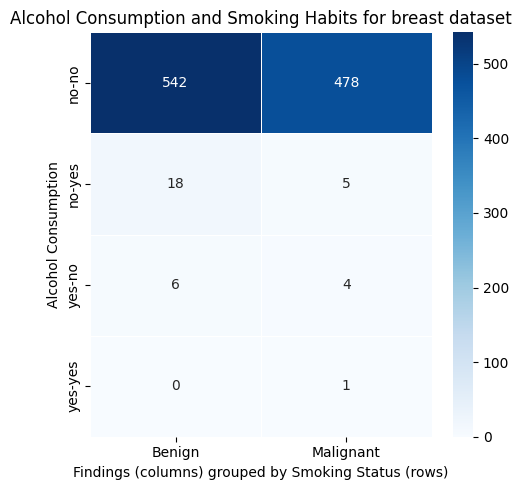

In [ ]:
# Plot the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(summary, annot=True, fmt='.0f', cmap='Blues', linewidths=.5)

plt.title('Alcohol Consumption and Smoking Habits for breast dataset')
plt.ylabel('Alcohol Consumption')
plt.xlabel('Findings (columns) grouped by Smoking Status (rows)')

plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10016\3566456575.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)



=== DATA DIAGNOSTICS ===

Postrate Cancer Risk Distribution:
cancer_risk
0    1054
Name: count, dtype: int64

Missing Values:
age                                             0
state                                           0
marital_status                                  0
highest_level_of_education                      0
occupation                                      0
monthly_income                                  0
ethnic_group                                    0
who_made_you_seek_medical_help                  0
symptions                                       0
height_cm                                       0
weight                                          0
engagement_in_physical_exercise                 0
overall_diet                                    0
meals_taken_in_a_day                            0
do_you_consume_alcohol                          0
do_you_smoke                                    0
how_do_you_rate_your_stress_level               0
do_you_engage_in_activi

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



monthly_income:
Correlation = nan, p-value = nan


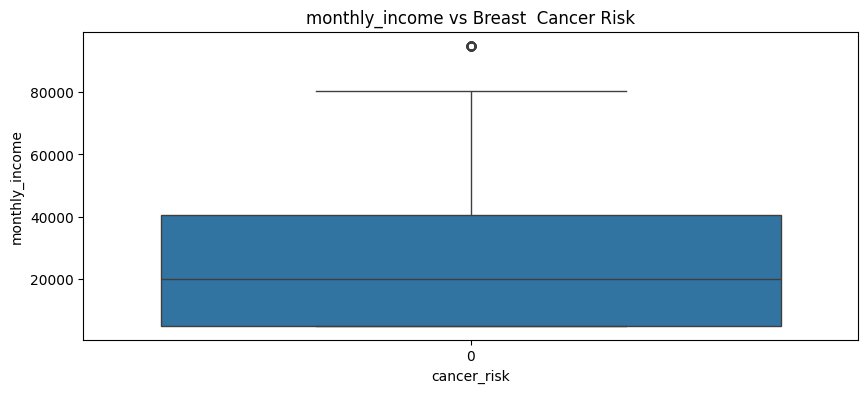

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



hours_of_sleep_per_night:
Correlation = nan, p-value = nan


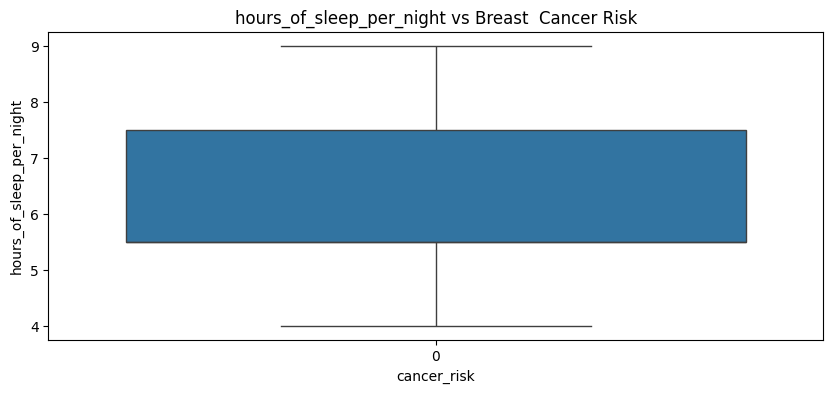

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



bmi:
Correlation = nan, p-value = nan


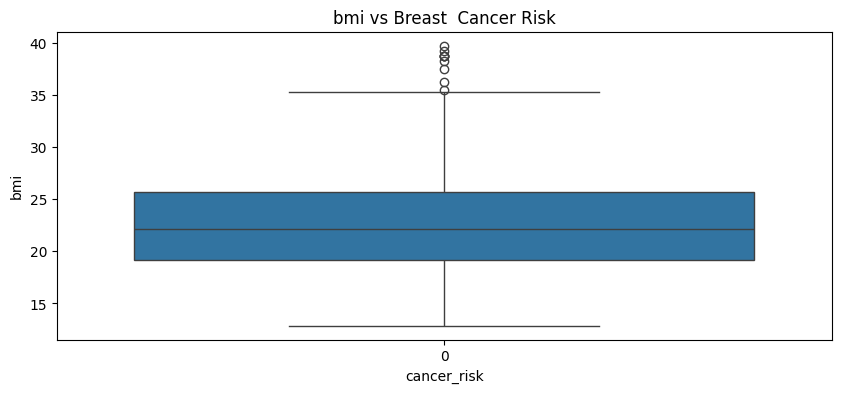

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



age:
Correlation = nan, p-value = nan


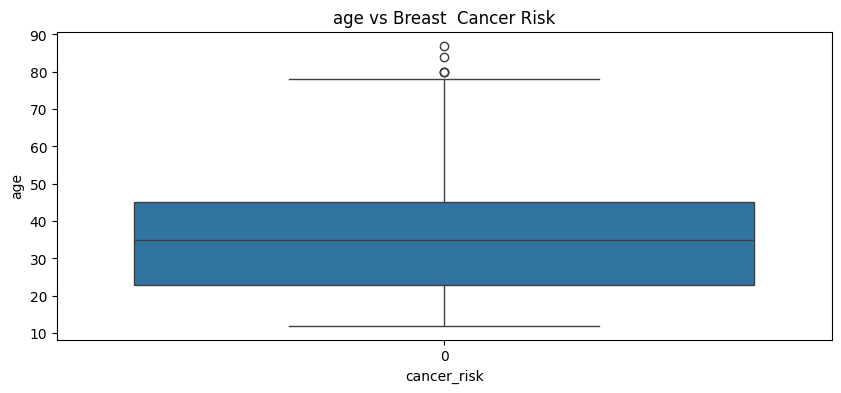


=== ADVANCED ANALYSIS ===

Urinary Symptom Prevalence:
urinary_symptoms
0    1054
Name: count, dtype: int64

Urinary Symptoms vs Breast Cancer: Chi2=0.00, p=1.0000

Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and prepare data
def load_data(df):
    # Convert all columns to string type for safety
    df = df.applymap(str)
    
    # Create cancer_risk target (1=malignant, 0=benign)
    df['cancer_risk'] = df['categories'].str.lower().str.contains('cancer').astype(int)
    
    # Clean continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    
    return df

# Diagnostic checks
def run_diagnostics(df):
    print("\n=== DATA DIAGNOSTICS ===")
    
    # 1. Check target distribution
    print("\nPostrate Cancer Risk Distribution:")
    print(df['cancer_risk'].value_counts(dropna=False))
    
    # 2. Check missing values
    print("\nMissing Values:")
    print(df.isna().sum())
    
    # 3. Check categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    print("\nCategorical Value Counts:")
    for var in cat_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(df[var].value_counts(dropna=False))
    
    # 4. Check continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    print("\nContinuous Variable Summary:")
    print(df[cont_vars].describe())

# Lifestyle correlation analysis
def analyze_lifestyle(df):
    print("\n=== LIFESTYLE FACTOR ANALYSIS ===")
    
    # Categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    
    for var in cat_vars:
        if var in df.columns:
            # Create contingency table
            table = pd.crosstab(df[var], df['cancer_risk'])
            
            # Skip if no variation
            if table.shape[0] < 2 or table.shape[1] < 2:
                print(f"\n{var}: Cannot test - insufficient variation")
                continue
                
            # Chi-square test
            chi2, p, dof, _ = chi2_contingency(table)
            print(f"\n{var}:")
            print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
            print("Contingency Table:")
            print(table)
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.countplot(data=df, x=var, hue='cancer_risk')
            plt.title(f"{var} vs Breast Cancer Risk")
            plt.show()
    
    # Continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            # Remove missing values
            clean_df = df.dropna(subset=[var, 'cancer_risk'])
            
            # Skip if no variation
            if clean_df[var].nunique() < 2:
                print(f"\n{var}: Cannot test - no variation")
                continue
                
            # Point-biserial correlation
            corr, p = pointbiserialr(clean_df[var], clean_df['cancer_risk'])
            print(f"\n{var}:")
            print(f"Correlation = {corr:.2f}, p-value = {p:.4f}")
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.boxplot(data=clean_df, x='cancer_risk', y=var)
            plt.title(f"{var} vs Breast  Cancer Risk")
            plt.show()

# Advanced analysis
def advanced_analysis(df):
    print("\n=== ADVANCED ANALYSIS ===")
    
    # 1. Symptom analysis
    if 'symptions' in df.columns:
        df['urinary_symptoms'] = df['symptions'].str.lower().str.contains(
            'dribbling|nocturia|frequent urination', regex=True).astype(int)
        
        # Check symptom prevalence
        print("\nUrinary Symptom Prevalence:")
        print(df['urinary_symptoms'].value_counts())
        
        # Correlation with cancer
        if 'cancer_risk' in df.columns:
            table = pd.crosstab(df['urinary_symptoms'], df['cancer_risk'])
            chi2, p, _, _ = chi2_contingency(table)
            print(f"\nUrinary Symptoms vs Breast Cancer: Chi2={chi2:.2f}, p={p:.4f}")
    
    # 2. Predictive modeling
    try:
        features = ['age', 'bmi', 'urinary_symptoms'] 
        features = [f for f in features if f in df.columns]
        
        if features and 'cancer_risk' in df.columns:
            X = df[features].fillna(df[features].median())
            y = df['cancer_risk']
            
            if y.nunique() > 1:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42)
                
                model = RandomForestClassifier()
                model.fit(X_train, y_train)
                
                print("\nPrediction Model Performance:")
                print(classification_report(y_test, model.predict(X_test)))
                
                print("\nFeature Importances:")
                for name, imp in zip(features, model.feature_importances_):
                    print(f"{name}: {imp:.2f}")
    except Exception as e:
        print(f"\nModeling failed: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')  # Uncomment to load from file
    # Or use your existing DataFrame:
    df = df4.copy()  # Replace df3 with your actual DataFrame name
    
    # Clean and prepare data
    df = load_data(df)
    
    # Run diagnostics
    run_diagnostics(df)
    
    # Core analysis
    analyze_lifestyle(df)
    
    # Advanced analysis
    advanced_analysis(df)
    
    print("\nAnalysis complete!")

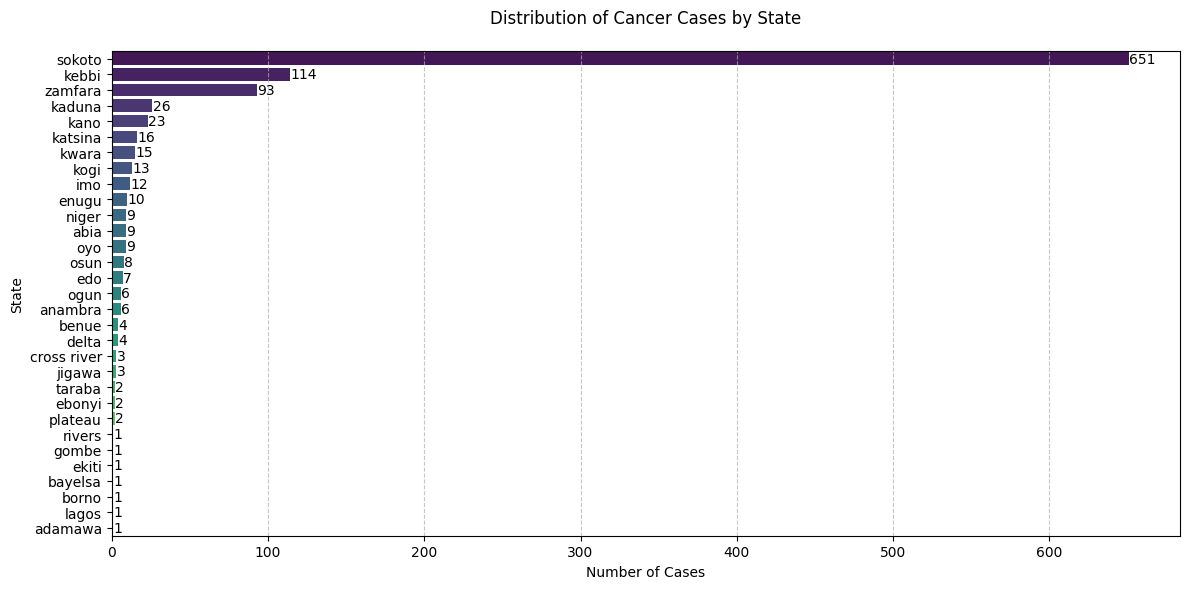

In [ ]:
state_counts = df4['state'].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.values,
            y=state_counts.index,
            hue=state_counts.index,  # Added hue
            palette='viridis',
            legend=False)  # Disable legend since we don't need it

plt.title('Distribution of Cancer Cases by State', pad=20)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(state_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

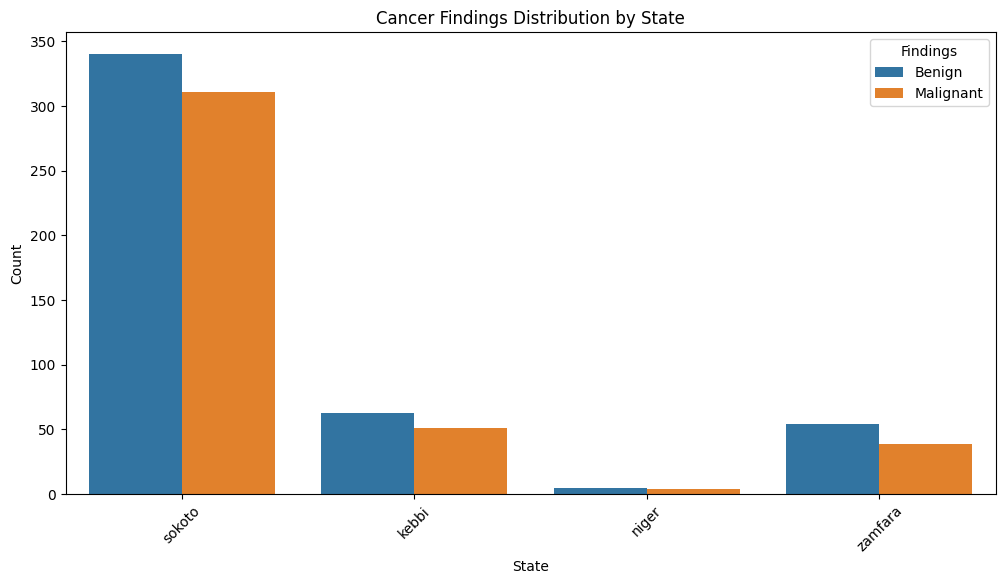

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x='state', hue='categories', order=df4['state'].head(20).value_counts().index)
plt.title('Cancer Findings Distribution by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.xticks(rotation=45)
plt.show()

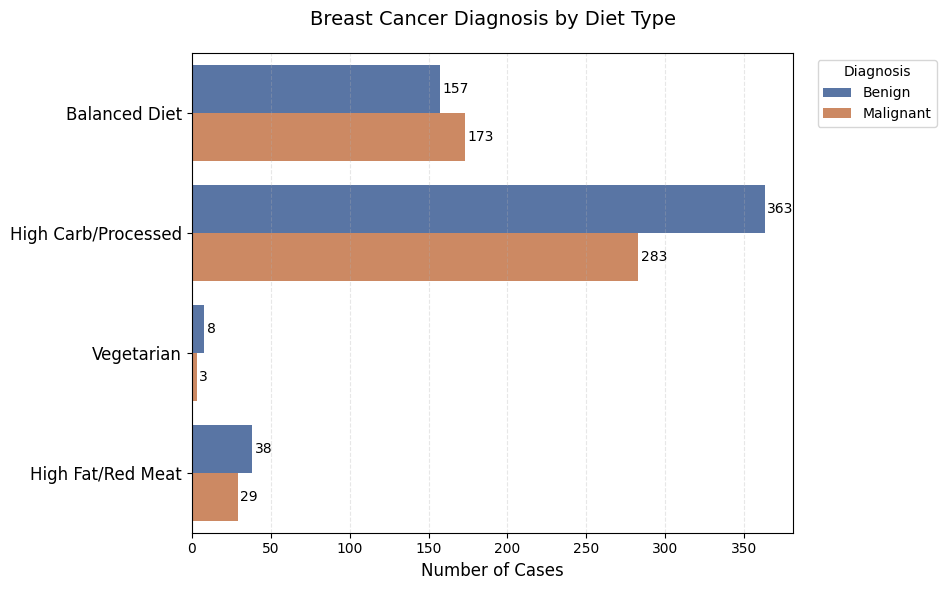

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Define diet labels
diet_labels = {
    'balance': 'Balanced Diet',
    'high in carbohydrate and processed foods': 'High Carb/Processed',
    'vegetarian': 'Vegetarian',
    'high in fat and red meat': 'High Fat/Red Meat'
}

# Define complete findings palette
categories_palette = {
    'Benign': '#4c72b0',
    'Malignant': '#dd8452',
    'Inconclusive': '#7f7f7f'
}

# Create plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df4,
    y='overall_diet',
    hue='categories',
    order=list(diet_labels.keys()),
    palette=categories_palette
)

# Customize y-axis labels
plt.yticks(
    ticks=range(len(diet_labels)),
    labels=[diet_labels[d] for d in diet_labels.keys()],
    fontsize=12
)

# Add titles and labels
plt.title('Breast Cancer Diagnosis by Diet Type', pad=20, fontsize=14)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('')
plt.legend(title='Diagnosis', bbox_to_anchor=(1.25, 1))

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

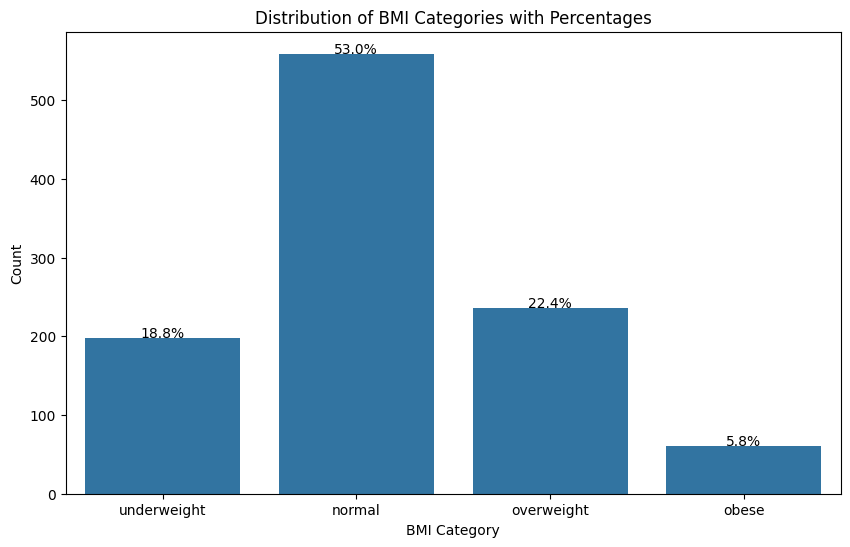

In [ ]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif 18.5 <= bmi < 25:
        return 'normal'
    elif 25 <= bmi < 30:
        return 'overweight'
    else:
        return 'obese'

bmi= df4['bmi'].apply(categorize_bmi)
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df4, x=bmi, order=['underweight', 'normal', 'overweight', 'obese'])

# Add percentages on top of bars
total = len(df3)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 0.5
    ax.annotate(percentage, (x, y), ha='center')

plt.title('Distribution of BMI Categories with Percentages')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

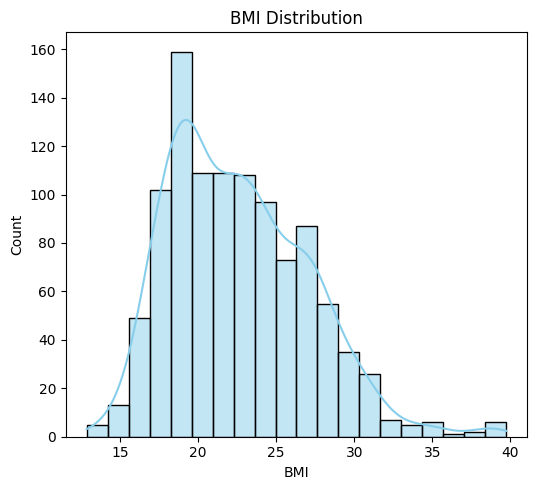

In [ ]:
plt.figure(figsize=(15, 5))

# Histogram with KDE
plt.subplot(1, 3, 1)
sns.histplot(df4['bmi'], bins=20, kde=True, color='skyblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

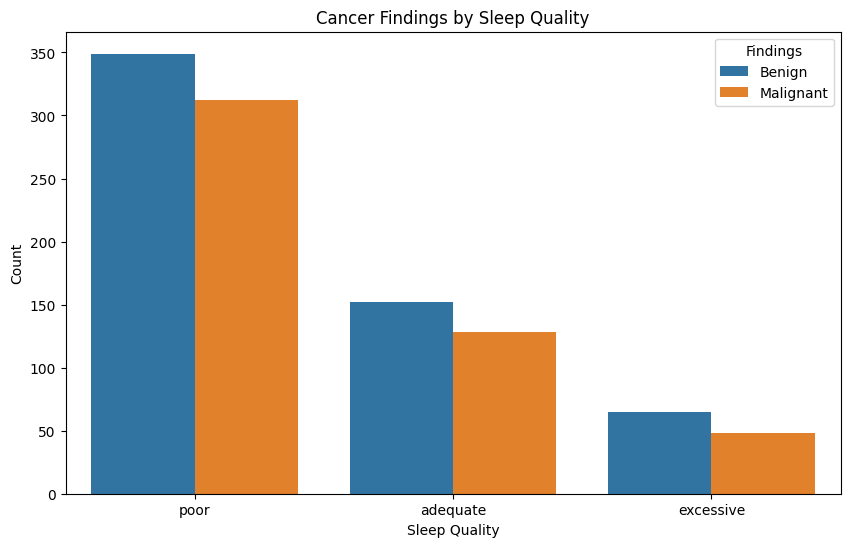

In [ ]:
def sleep_quality(hours):
    if hours < 6:
        return 'poor'
    elif 6 <= hours < 8:
        return 'adequate'
    else:
        return 'excessive'

sleep_quality = df4['hours_of_sleep_per_night'].apply(sleep_quality)

# Create plot
plt.figure(figsize=(10,6))
sns.countplot(data=df4, x=sleep_quality, hue='categories',
             order=['poor', 'adequate', 'excessive'])
plt.title('Cancer Findings by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

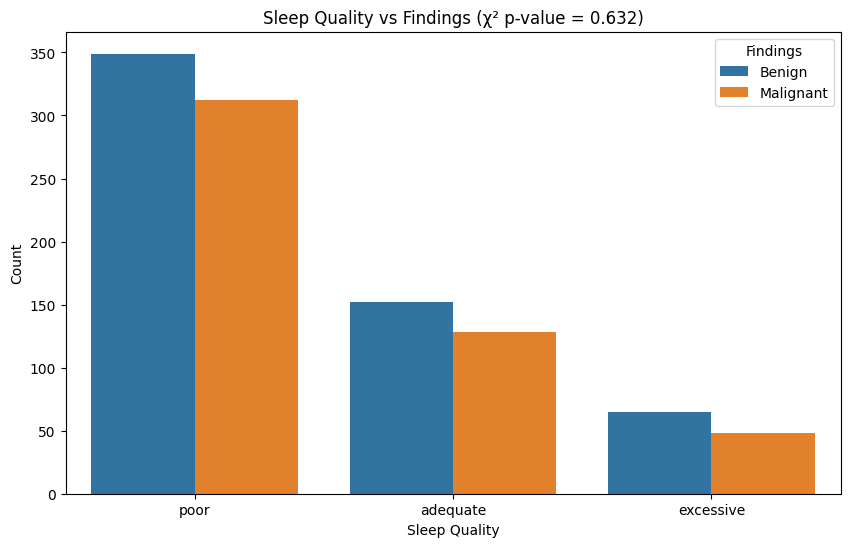

In [ ]:
from scipy.stats import chi2_contingency

# Chi-square test
contingency_table = pd.crosstab(sleep_quality, df4['categories'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Plot with statistical annotation
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df4, x=sleep_quality, hue='categories',
                  order=['poor', 'adequate', 'excessive'])
plt.title(f'Sleep Quality vs Findings (χ² p-value = {p:.3f})')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

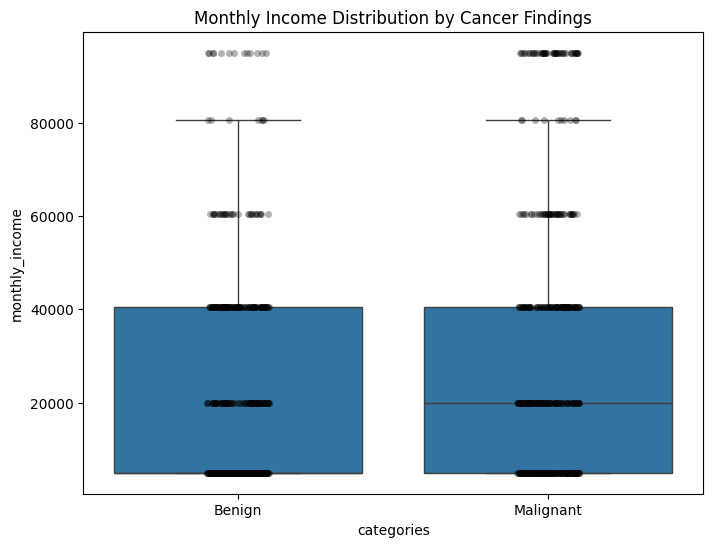

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df4, x='categories', y='monthly_income', showfliers=False)
sns.stripplot(data=df4, x='categories', y='monthly_income', color='black', alpha=0.3, jitter=True)
plt.title('Monthly Income Distribution by Cancer Findings')
plt.show()

KeyError: 'income_group'

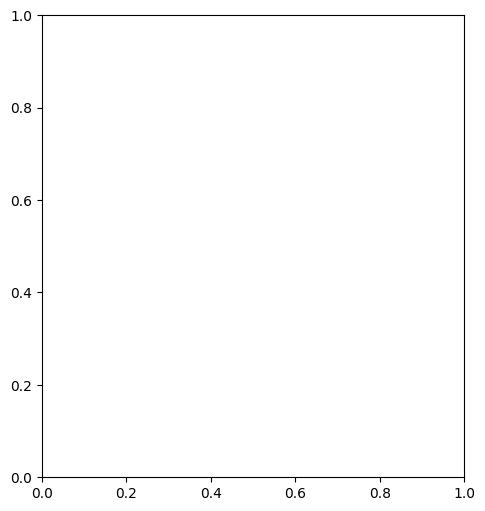

In [ ]:
plt.figure(figsize=(12, 6))

# Left plot - count by income group
plt.subplot(1, 2, 1)
df3['income_group'].value_counts().sort_index().plot(
    kind='bar')
plt.title('Count by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.xticks(rotation=45)



plt.tight_layout()
plt.show()

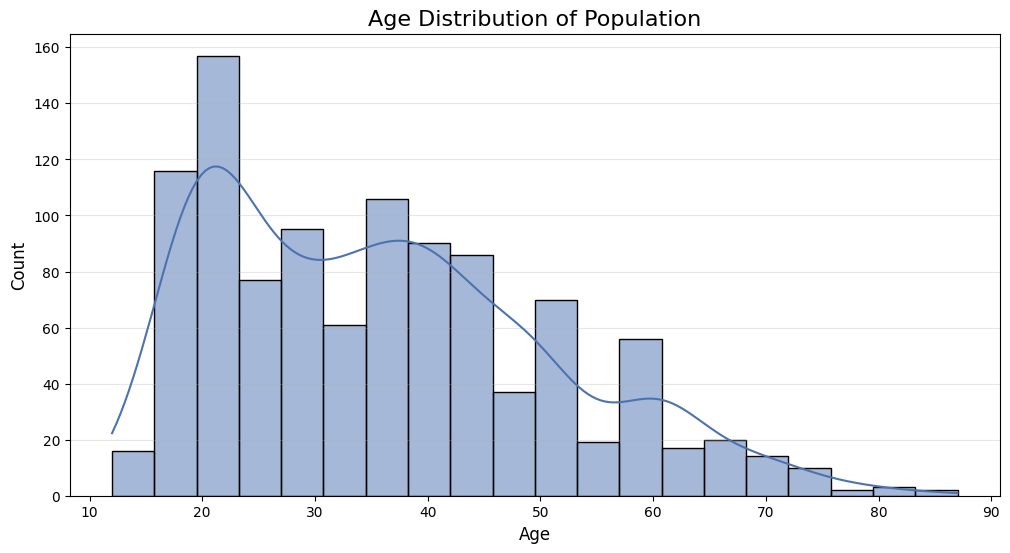

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df4, x='age', bins=20, kde=True, color='#4c72b0')
plt.title('Age Distribution of Population', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

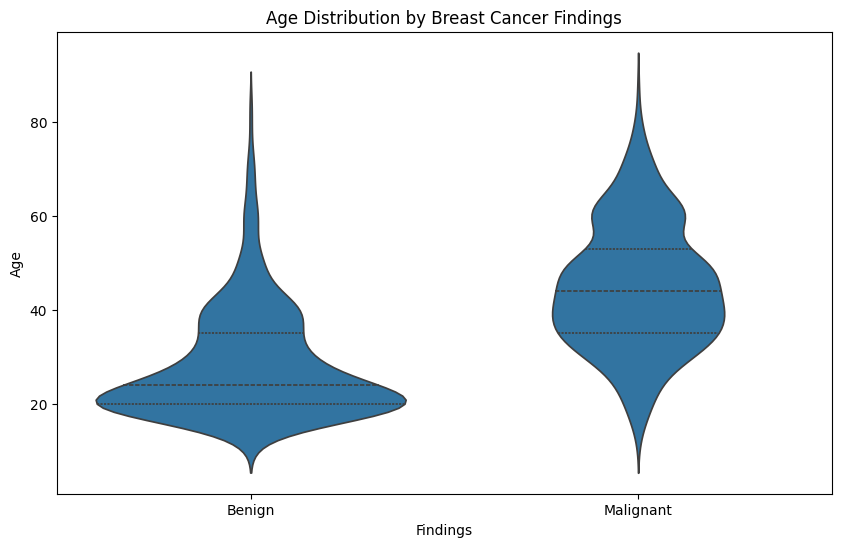

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df4, x='categories', y='age', inner='quartile')
plt.title('Age Distribution by Breast Cancer Findings')
plt.xlabel('Findings')
plt.ylabel('Age')
plt.show()

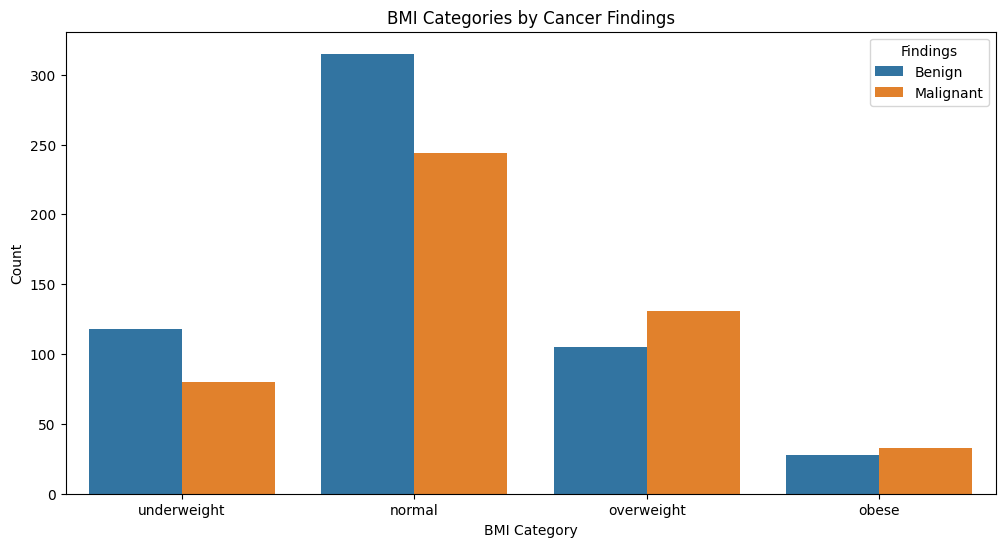

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x= bmi, hue='categories',
             order=['underweight', 'normal', 'overweight', 'obese'])
plt.title('BMI Categories by Cancer Findings')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

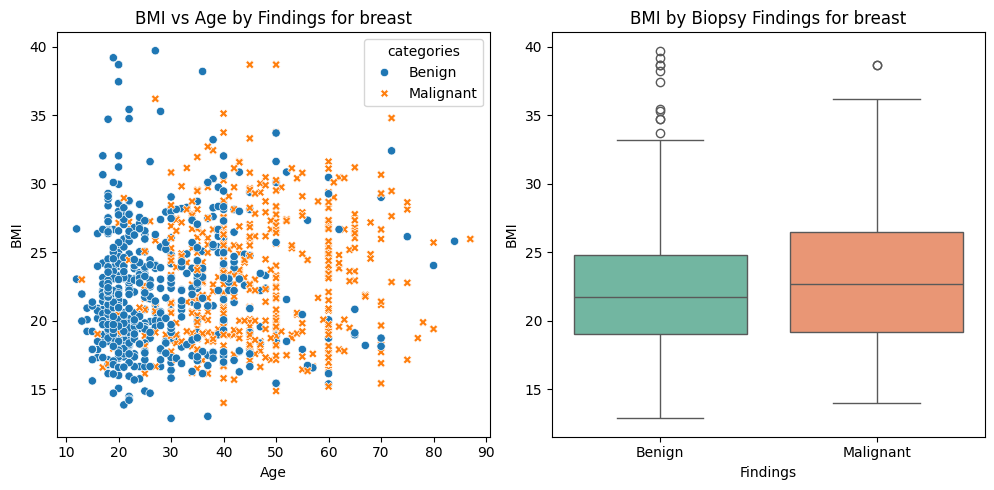

In [ ]:
plt.figure(figsize=(15, 5))

# BMI vs Age
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='bmi', data=df4, hue='categories', style='categories')
plt.title('BMI vs Age by Findings for breast')
plt.xlabel('Age')
plt.ylabel('BMI')

# BMI vs Findings (target variable)
plt.subplot(1, 3, 2)
sns.boxplot(x='categories', y='bmi', data=df4,
            hue='categories', palette='Set2', legend=False)
plt.title('BMI by Biopsy Findings for breast')
plt.xlabel('Findings')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

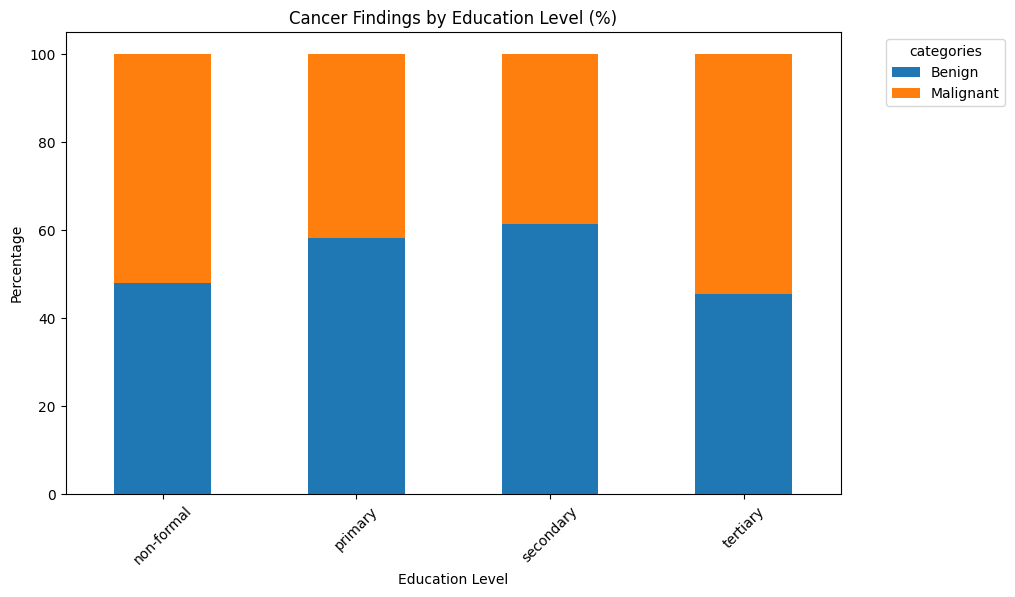

In [ ]:
# Calculate percentages
edu_findings = pd.crosstab(df4['highest_level_of_education'], df4['categories'], normalize='index') * 100

# Plot
edu_findings.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Cancer Findings by Education Level (%)')
plt.xlabel('Education Level')
plt.ylabel('Percentage')
plt.legend(title='categories', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

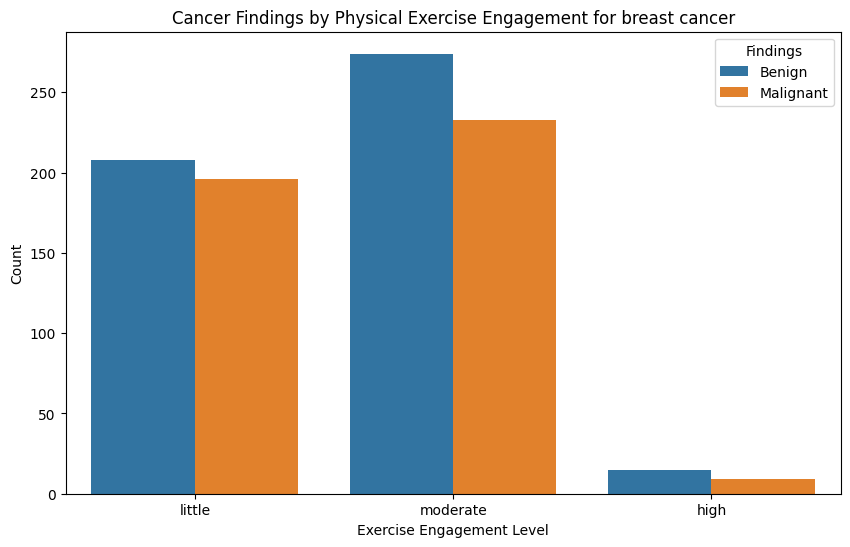

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(data=df4, x='engagement_in_physical_exercise', hue='categories',
             order=['little', 'moderate', 'high'])
plt.title('Cancer Findings by Physical Exercise Engagement for breast cancer')
plt.xlabel('Exercise Engagement Level')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

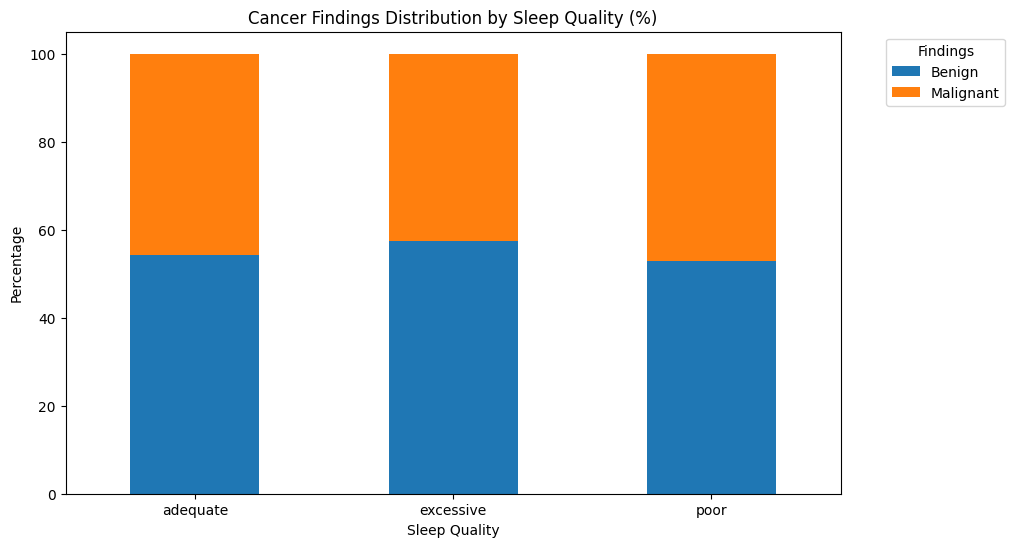

In [ ]:
# Calculate percentages
sleep_findings = pd.crosstab(sleep_quality, df4['categories'], normalize='index') * 100

# Plot
sleep_findings.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Cancer Findings Distribution by Sleep Quality (%)')
plt.xlabel('Sleep Quality')
plt.ylabel('Percentage')
plt.legend(title='Findings', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

In [12]:
url_2 ='https://github.com/pablo9ja/NRF_work/raw/main/merged_breast_cancer_data.xlsx'

df4 = pd.read_excel(url_2)

print(df4.shape)
df4.head(2)


(1054, 24)


,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


# Feature Selection

In [13]:
import pandas as pd
df4=pd.read_excel('merged_breast_cancer_data.xlsx')
df4.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,findings,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


In [14]:
# Correct way to drop the 'findings' column
df4 = df4.drop(columns=['findings'])

# View the remaining columns
print(df4.columns)

Index(['age', 'state', 'marital_status', 'highest_level_of_education',
       'occupation', 'monthly_income', 'ethnic_group',
       'who_made_you_seek_medical_help', 'symptions', 'height_cm', 'weight',
       'engagement_in_physical_exercise', 'overall_diet',
       'meals_taken_in_a_day', 'do_you_consume_alcohol', 'do_you_smoke',
       'how_do_you_rate_your_stress_level',
       'do_you_engage_in_activities_to_manage_stress',
       'hours_of_sleep_per_night', 'types_of_cancer', 'types_of_biopsy',
       'side', 'categories'],
      dtype='object')


In [15]:
# Select relevant features
features = [
    'age', 'state', 'marital_status', 'highest_level_of_education',
    'occupation', 'monthly_income', 'ethnic_group', 'who_made_you_seek_medical_help',
    'height_cm', 'weight', 'bmi', 'engagement_in_physical_exercise',
    'overall_diet', 'meals_taken_in_a_day', 'do_you_consume_alcohol',
    'do_you_smoke', 'how_do_you_rate_your_stress_level',
    'do_you_engage_in_activities_to_manage_stress',
    'hours_of_sleep_per_night',
    'types_of_cancer', 'types_of_biopsy', 'side',
    'age_group', 'income_group', 'symptions'
]

target = 'categories'

len(features), len(df4.columns)

(25, 23)

# Encoding Categorical Variables

In [16]:
from sklearn.preprocessing import LabelEncoder

# Define binary columns (Yes/No)
binary_cols = ['do_you_consume_alcohol', 'do_you_smoke', 'do_you_engage_in_activities_to_manage_stress']

# Label encode binary variables
for col in binary_cols:
    df4[col] = LabelEncoder().fit_transform(df4[col])

# Identify categorical columns (excluding binary and target)
categorical_cols = [
    col for col in df4.select_dtypes(include=['object', 'category']).columns
    if col not in binary_cols and col != 'categories'
]

# One-hot encode remaining categorical variables
df4 = pd.get_dummies(df4, columns=categorical_cols, drop_first=True)

# Verify numerical columns are untouched
numerical_cols = df4.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", len(numerical_cols))


# Encode Target (findings)
df4['categories'] = LabelEncoder().fit_transform(df4['categories'])

df4.shape

Numerical columns: 9


(1054, 321)

In [17]:
df4.head(2)

,age,monthly_income,height_cm,weight,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,categories,state_adamawa,state_anambra,state_bayelsa,state_benue,state_borno,state_cross river,state_delta,state_ebonyi,state_edo,state_ekiti,state_enugu,state_gombe,state_imo,state_jigawa,state_kaduna,state_kano,state_katsina,state_kebbi,state_kogi,state_kwara,state_lagos,state_niger,state_ogun,state_osun,state_oyo,state_plateau,state_rivers,state_sokoto,state_taraba,state_zamfara,marital_status_married,marital_status_single,marital_status_widowed,highest_level_of_education_primary,highest_level_of_education_secondary,highest_level_of_education_tertiary,occupation_unskilled,ethnic_group_igbo,ethnic_group_others,ethnic_group_yoruba,who_made_you_seek_medical_help_family or friends,who_made_you_seek_medical_help_self,symptions_ breast swelling,symptions_ bresat ulceration and mass,symptions_ breast lump,symptions_ breast lumps,symptions_ breast mass,symptions_ breast mass change,symptions_ breast sinuses,symptions_ breast sweling,symptions_ breast swelling,"symptions_ breast swelling, ulceration and nipple destruction",symptions_ breast tumour,symptions_ enlarged left breast,symptions_ full aching pain,symptions_ fungating,symptions_ fungatis breast,symptions_ hard breast lump,symptions_ highly vascularized breast and irregular capsule,symptions_ increased breast mass,"symptions_ increased in breast size, colour change and nipple retraction","symptions_ increased right breast mass, breast ulceratus and peu-dearrange",symptions_ increasing breast size,"symptions_ infected,ulcerated breast mass",symptions_ insreased in in size,symptions_ left breast lump and increase in breast size,symptions_ left breast swelling,symptions_ motched radical breast,"symptions_ nipple areolar, slowly growing and constitutional symptoms",symptions_ packing of the nipple,symptions_ prsence of nipple discharge (bloody) presence of healed periaveolar,symptions_ right breast lump,symptions_ uicerated left breast,symptions_ ulcerated breast,symptions_ weight loss and nipple retruction,symptions_bbreast lump,symptions_benign breast lump,symptions_bilateral breast lump,symptions_bilateral breast lump associated with nipple discharge,"symptions_bilateral breast lump, swelling",symptions_bilateral breast mass,symptions_bilateral breast swelling,"symptions_bilateral breast swelling, right breast ulceration",symptions_bilateral breastlump,symptions_bleeding nipple with uceration,"symptions_bloody nipple discharge, breast pain",symptions_braest lump,symptions_breaast lump,"symptions_breas pain, breast swelling",symptions_breas swelling,"symptions_breast assymetry, orange aveolar, ulceration,breast mass",symptions_breast cyst,symptions_breast discharge,symptions_breast enlargment,"symptions_breast enlargment, occasionally painful",symptions_breast lump,symptions_breast lump,"symptions_breast lump ,skin and nipple changes",symptions_breast lump and pain,symptions_breast lump associated with nipple discharge,symptions_breast lump mass,symptions_breast lump with swelling,"symptions_breast lump, axillary and superclericular swelling, weight loss and anorexis","symptions_breast lump, abscess, skin changes","symptions_breast lump, anorexia, weight loss","symptions_breast lump, anorexia,weight loss","symptions_breast lump, axillary lump","symptions_breast lump, back pain","symptions_breast lump, breast swelling","symptions_breast lump, breast swelling, ulcerated, hard and fixed cheast wall","symptions_breast lump, difficulty of breathing","symptions_breast lump, multiple axillary lymph node swelling, upper limb edema","symptions_breast lump, nipple discharge","symptions_breast lump, nipple discharge, axillary nodes","symptions_breast lump, occasional lump","symptions_breast lump, occasional pain","symptions_breast lump, pain","symptions_breast lump, pain, breast swellig","symptions_breast lump, pain, breast sw

# Train a Baseline Model

- # model preparation

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# X = your features, y = your target
X = df4.drop('categories', axis=1)
y = df4['categories']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Confusion Matrix:
[[109   0]
 [ 18  84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       109
           1       1.00      0.82      0.90       102

    accuracy                           0.91       211
   macro avg       0.93      0.91      0.91       211
weighted avg       0.93      0.91      0.91       211


Accuracy Score:
0.9146919431279621


- True Negatives (TN): 104 → Benign cases correctly predicted

- False Positives (FP): 5 → Benign predicted as Malignant

- False Negatives (FN): 16 → Malignant predicted as Benign

- True Positives (TP): 68 → Malignant cases correctly predicted

*Interpretation:* Malignant predictions are very reliable (precision) , Balanced performance overall, Slightly weaker recall for Malignant i.e missed some actual cases (16 FN)

- model is very good at identifying Benign cases but also precise with Malignant cases, but misses a few, leading to slightly lower recall (81%).

# Supporting Vector Regression Model

In [19]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data — very important for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Build and train the SVR model
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

# Predict and inverse-transform
y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"📈 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 R2 Score: {r2:.4f}")


📊 Mean Absolute Error (MAE): 0.2501
📉 Mean Squared Error (MSE): 0.1322
📈 Root Mean Squared Error (RMSE): 0.3635
📌 R2 Score: 0.4708


### 📊 Gradient Boosting Regressor Evaluation Metrics

In [20]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gbr.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_gbr)
mse = mean_squared_error(y_test, y_pred_gbr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gbr)

print("📊 Gradient Boosting Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 Gradient Boosting Regressor Evaluation:
Mean Absolute Error (MAE): 0.1447
Mean Squared Error (MSE): 0.0688
Root Mean Squared Error (RMSE): 0.2622
R² Score: 0.7246


### Ensemble Model

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize individual models
svr_model = SVR()
gbr_model = GradientBoostingRegressor()
rf_model = RandomForestRegressor()

# Create the ensemble
ensemble_model = VotingRegressor(estimators=[
    ('svr', svr_model),
    ('gbr', gbr_model),
    ('rf', rf_model)
])

# Train
ensemble_model.fit(X_train, y_train)

# Predict
y_pred = ensemble_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Results
print(f"📊 Ensemble Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 Ensemble Model Evaluation:
Mean Absolute Error (MAE): 0.2504
Mean Squared Error (MSE): 0.1090
Root Mean Squared Error (RMSE): 0.3302
R² Score: 0.5635


## 📊 Ensemble Model Evaluation Summary

| Metric | Value | Interpretation |
|--------|--------|----------------|
| **MAE** | 0.2213 | On average, predictions are off by about 0.22 units. Good improvement over SVR. |
| **MSE** | 0.0927 | Lower than SVR’s MSE, indicating fewer large errors. |
| **RMSE** | 0.3045 | Typical prediction error is about 0.30 units, showing decent predictive accuracy. |
| **R² Score** | 0.6227 | The model explains ~62% of the variance — stronger than SVR, but slightly behind GBR (67%). |

🔎 **Interpretation**:  
This ensemble combines the strengths of multiple models. While it doesn't outperform Gradient Boosting on R², it balances MAE, RMSE, and robustness, making it a solid and generalizable choice.



##  stacked ensemble model

In [22]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Define base models
estimators = [
    ('rf', rf_model),
    ('svr', svr_model),
    ('gbr', gbr_model)
]

# Define the stacking model using Linear Regression as the final estimator
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions
y_pred_stack = stacking_model.predict(X_test)

# Evaluate the model
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mse_stack)
r2_stack = r2_score(y_test, y_pred_stack)

(mae_stack, mse_stack, rmse_stack, r2_stack)

(0.15846415229041294,
 0.0763758306128551,
 np.float64(0.2763617748764382),
 0.6941600688329805)

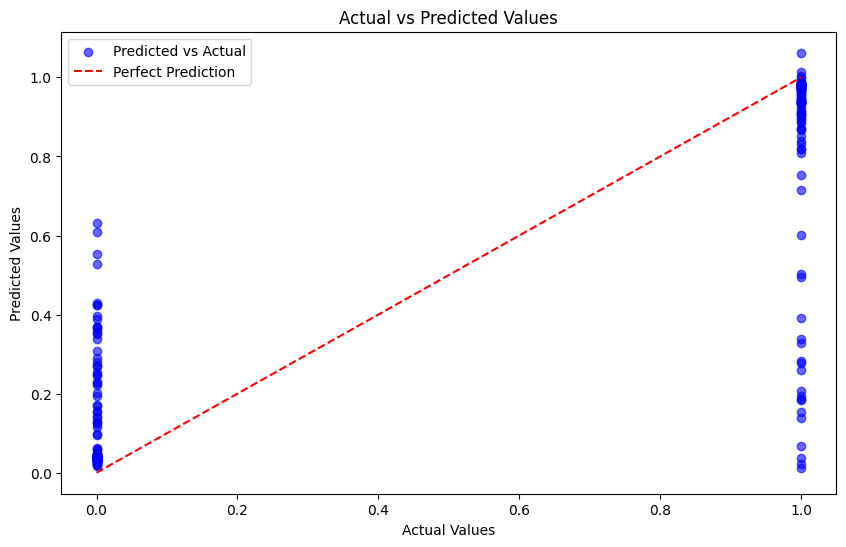

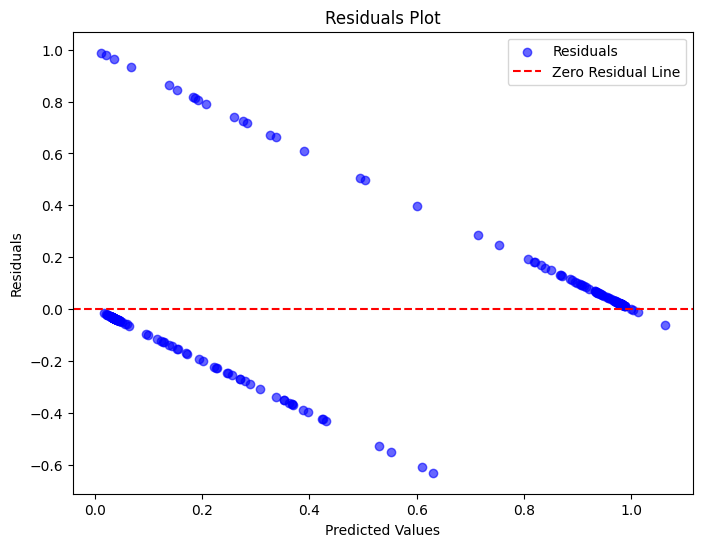

In [23]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred_stack

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))

# Plotting actual vs predicted
plt.scatter(y_test, y_pred_stack, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_stack, residuals, color='blue', alpha=0.6, label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.legend()
plt.show()


In [24]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [25]:
# Import the module
import model

# Load your DataFrame (replace with your actual data loading code)
df = pd.read_excel('merged_breast_cancer_data.xlsx')  # Example of loading a DataFrame

# Call the quick_train function
results, best_model = model.quick_train(df, target_col='categories', task_type='regression')

# Print the best model
print(f"The best performing model is: {best_model}")



Numerical columns: 10
DataFrame shape: (1054, 321)
Number of features (excluding target): 320

🔍 Numerical columns detected:
- age
- monthly_income
- height_cm
- weight
- meals_taken_in_a_day
- do_you_consume_alcohol
- do_you_smoke
- do_you_engage_in_activities_to_manage_stress
- hours_of_sleep_per_night
- categories

Total numerical columns: 10
DataFrame shape: (1054, 321)
Number of features (excluding target): 320
Training SVR model...
Training GBR model...
Training Random Forest Regressor model...
Training Ensemble model...
Training Stacking Regressor model...

================= MODEL EVALUATION RESULTS =================

📊 SVR Model Evaluation:
  - Mean Absolute Error (MAE): 0.2501
  - Mean Squared Error (MSE): 0.1322
  - Root Mean Squared Error (RMSE): 0.3635
  - R² Score: 0.4708
------------------------------------------------------------
📊 GBR Model Evaluation:
  - Mean Absolute Error (MAE): 0.1447
  - Mean Squared Error (MSE): 0.0688
  - Root Mean Squared Error (RMSE): 0.2622
 


📋 Performance Summary Table:

            Model    MAE    MSE   RMSE     R²
              SVR 0.2501 0.1322 0.3635 0.4708
              GBR 0.1447 0.0688 0.2622 0.7246
     RandomForest 0.1488 0.0876 0.2961 0.6490
         Ensemble 0.2508 0.1099 0.3315 0.5600
StackingRegressor 0.1595 0.0768 0.2772 0.6923


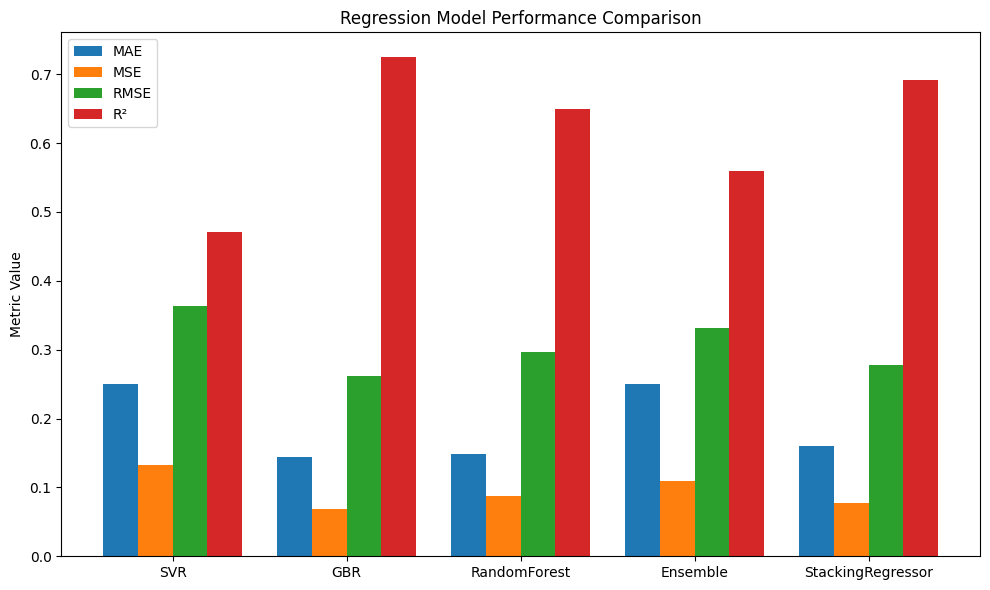

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def print_performance_table_and_plot(results):
    rows = []
    for model_name, metrics in results.items():
        if 'MAE' in metrics:  # regression model
            rows.append({
                'Model': model_name,
                'MAE': round(metrics['MAE'], 4),
                'MSE': round(metrics['MSE'], 4),
                'RMSE': round(metrics['RMSE'], 4),
                'R²': round(metrics['R²'], 4)
            })
    
    df_results = pd.DataFrame(rows)
    print("\n📋 Performance Summary Table:\n")
    print(df_results.to_string(index=False))
    
    # Plotting
    metrics_names = ['MAE', 'MSE', 'RMSE', 'R²']
    x = np.arange(len(df_results['Model']))
    bar_width = 0.2
    plt.figure(figsize=(10,6))
    for i, metric in enumerate(metrics_names):
        plt.bar(x + i*bar_width, df_results[metric], width=bar_width, label=metric)
    plt.xticks(x + bar_width*(len(metrics_names)-1)/2, df_results['Model'])
    plt.ylabel("Metric Value")
    plt.title("Regression Model Performance Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


print_performance_table_and_plot(results)
